# Geometric Phases on Parameter Grids: Berry Curvature, Chern Numbers and Zak Phases

Author: sdoygb, 2026

### Introduction

When a quantum system depends on external parameters $\theta$, the
adiabatic transport of an eigenstate around a closed loop in parameter
space accumulates a geometric phase — the **Berry phase** — that is
independent of the instantaneous energy and depends only on the geometry
of the eigenstate bundle. Its local density, the **Berry curvature**
$F(\theta)$, integrates to a topological invariant, the **Chern number**
$C = \frac{1}{2\pi}\int F$, which is quantized to an integer and
underlies phenomena such as the quantum Hall effect and topological
insulators.

This notebook demonstrates `qutip.berry`, a small dependency-light module
proposed in [qutip/qutip#2972](https://github.com/qutip/qutip/issues/2972)
that restores and modernizes the geometric-phase toolkit
(`qutip.topology.berry_curvature`) removed in QuTiP 5.0. It provides:

- `berry_curvature(eigfs, periodic)` — the discretized Berry curvature
  on a two-dimensional parameter grid, using the
  Fukui–Hatsugai–Suzuki (FHS) link-variable formulation for a single
  band. Because each plaquette flux is wrapped into $(-\pi, \pi]$, the
  summed Chern number is *exactly integral for any grid size*;
- `chern_number(eigfs, periodic)` — the summed curvature divided by
  $2\pi$;
- `berry_phase(eigfs)` — a one-dimensional Wilson loop giving the
  Berry/Zak phase along a closed path;
- multi-band support: when several eigenstates are supplied, the
  curvature is assembled from the determinant of the Wilson loop around
  each plaquette (valid when the bands do not mix), and each grid
  dimension can be flagged periodic independently.

All outputs are gauge invariant by construction — the link variables
absorb the arbitrary phases of the eigenstates, so the user never has to
fix a gauge by hand. The module consumes plain NumPy arrays or nested
lists of `Qobj` kets, so it composes directly with `Qobj.eigenstates()`.

We walk through: a monopole on the sphere ($C = +1$), the
Qi–Wu–Zhang lattice models on the torus ($C = +1$ and $C = -2$), a
three-sector **zero-sum consistency test** ($C_A + C_B + C_C = 0$ to
machine precision), the Zak phase of the SSH chain ($\pi$ vs $0$), the
multi-band Wilson-loop formulation, and finally gauge invariance and
mesh convergence.

> **Note.** This notebook runs against the QuTiP development build that
> includes `qutip.berry` (the module under review in qutip/qutip#2972).
> It is intended to become a user guide in the
> [qutip-tutorials](https://github.com/qutip/qutip-tutorials) repository
> once the module is merged into QuTiP.

### Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qutip
from qutip import Qobj, sigmax, sigmay, sigmaz
import qutip.berry as berry

%matplotlib inline

We first define a small helper that samples the eigenstates of a
Hamiltonian family $H(p_0, p_1)$ on a regular grid, in the exact layout
consumed by `qutip.berry`: `(n0, n1, hilbert)` for a single band, or
`(n0, n1, nocc, hilbert)` for several bands.

In [2]:
def eigenstates_grid(h_func, p0, p1, bands=None):
    """Sample eigenstates of the Hamiltonian family h_func(p0, p1) on a grid.

    Parameters
    ----------
    h_func : callable
        h_func(a, b) -> Qobj, a Hermitian Hamiltonian family.
    p0, p1 : array_like
        The discrete values of the two parameters.
    bands : list of int or None
        Which eigenstates to keep.  None keeps all bands and returns an
        array of shape (n0, n1, nocc, hilbert); a single band returns
        (n0, n1, hilbert).

    Returns
    -------
    ndarray
        The (complex) eigenstates on the grid.
    """
    n0, n1 = len(p0), len(p1)
    hilbert = Qobj(h_func(p0[0], p1[0])).shape[0]
    if bands is None:
        grid = np.empty((n0, n1, hilbert, hilbert), dtype=complex)
        pick = lambda ek: [ek[b].full().reshape(-1) for b in range(hilbert)]
    else:
        grid = np.empty((n0, n1, len(bands), hilbert), dtype=complex)
        pick = lambda ek: [ek[b].full().reshape(-1) for b in bands]
    for i, a in enumerate(p0):
        for j, b in enumerate(p1):
            grid[i, j] = pick(Qobj(h_func(a, b)).eigenstates()[1])
    return grid.squeeze() if bands is not None and len(bands) == 1 else grid

### The monopole on the sphere: Berry curvature and $C = +1$

Consider a spin-1/2 in the magnetic field of a *winding-1 hedgehog* on
the unit sphere,

$$H(\theta, \varphi) = -\big(\sin\theta\cos\varphi\,\sigma_x +
\sin\theta\sin\varphi\,\sigma_y + \cos\theta\,\sigma_z\big),$$

with the minus sign making the *occupied* (ground) band carry Chern
number $C = +1$.  The parameter space is a sphere: $\theta \in [0, \pi]$
is an open axis, while $\varphi \in [0, 2\pi)$ is closed, so we flag the
second axis periodic — the link crossing the grid boundary is then
included and we recover exactly one flux quantum.

In [3]:
def monopole(theta, phi, winding=1):
    """Inverted monopole: H = -B . sigma with B a winding-n hedgehog field."""
    Bx = np.sin(theta) * np.cos(winding * phi)
    By = np.sin(theta) * np.sin(winding * phi)
    Bz = np.cos(theta)
    return -(Bx * sigmax() + By * sigmay() + Bz * sigmaz())


n_theta, n_phi = 80, 80
thetas = np.linspace(0, np.pi, n_theta)
phis = np.linspace(0, 2 * np.pi, n_phi, endpoint=False)

psi_mono = eigenstates_grid(monopole, thetas, phis, bands=[0])
F_mono = berry.berry_curvature(psi_mono, periodic=(False, True))
C_mono = berry.chern_number(psi_mono, periodic=(False, True))
print("Chern number of the occupied band: C =", C_mono)

Chern number of the occupied band: C = 1.0000000000000093


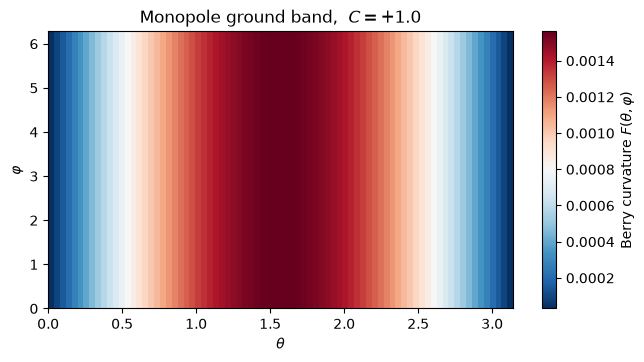

In [4]:
plt.figure(figsize=(7.5, 3.6))
plt.imshow(F_mono.T, origin="lower", aspect="auto",
           extent=[0, np.pi, 0, 2 * np.pi], cmap="RdBu_r")
plt.colorbar(label=r"Berry curvature $F(\theta,\varphi)$")
plt.xlabel(r"$\theta$")
plt.ylabel(r"$\varphi$")
plt.title(f"Monopole ground band,  $C = {C_mono:+.1f}$")
plt.show()

The curvature is strongly peaked near the south pole — the hedgehog's
flux is spread over the sphere with the winding concentrated where the
field texture varies fastest — and integrates to exactly $+1$.

### Chern numbers on the torus: the Qi–Wu–Zhang model

The Qi–Wu–Zhang (QWZ) model on the square lattice has the Bloch
Hamiltonian

$$H(k_1, k_2) = \sin k_1\,\sigma_x + \sin k_2\,\sigma_y +
(1 - \cos k_1 - \cos k_2)\,\sigma_z,$$

whose lower band carries $C = +1$ on the Brillouin-zone torus $T^2$.
Its *double cover*, with $\sin k_1 \to \sin 2k_1$ and
$1 - \cos k_1 \to -1 - \cos 2k_1$, realizes $C = -2$.  Both axes of the
torus are periodic, so we pass `periodic=(True, True)`.

In [5]:
def qwz(k1, k2, double_cover=False):
    """Qi-Wu-Zhang Hamiltonian (lower band C = +1), or its double cover
    (C = -2), on the Brillouin-zone torus."""
    if double_cover:
        return (np.sin(2 * k1) * sigmax() + np.sin(k2) * sigmay()
                + (-1 - np.cos(2 * k1) - np.cos(k2)) * sigmaz())
    return (np.sin(k1) * sigmax() + np.sin(k2) * sigmay()
            + (1 - np.cos(k1) - np.cos(k2)) * sigmaz())


n_k = 60
ks = np.linspace(0, 2 * np.pi, n_k, endpoint=False)

psi_qwz = eigenstates_grid(lambda k1, k2: qwz(k1, k2), ks, ks, bands=[0])
psi_qwz2 = eigenstates_grid(lambda k1, k2: qwz(k1, k2, True), ks, ks, bands=[0])

C_qwz = berry.chern_number(psi_qwz, periodic=(True, True))
C_qwz2 = berry.chern_number(psi_qwz2, periodic=(True, True))
print("QWZ:            C =", C_qwz)
print("double cover:   C =", C_qwz2)

QWZ:            C = 1.0000000000000009
double cover:   C = -1.999999999999996


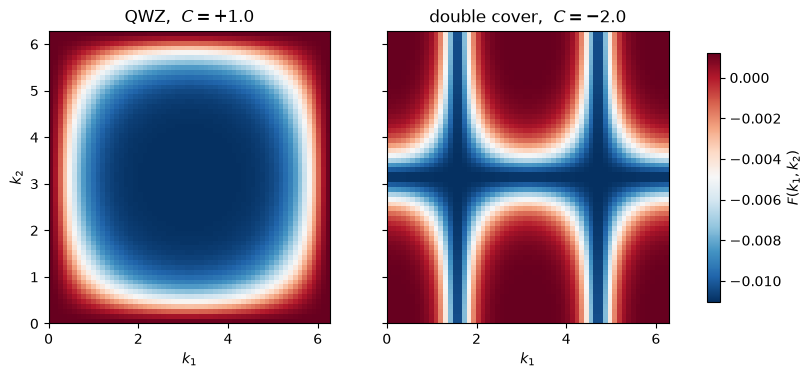

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
for ax, F, title in [
    (axes[0], berry.berry_curvature(psi_qwz, periodic=(True, True)),
     f"QWZ,  $C = {C_qwz:+.1f}$"),
    (axes[1], berry.berry_curvature(psi_qwz2, periodic=(True, True)),
     f"double cover,  $C = {C_qwz2:+.1f}$"),
]:
    im = ax.imshow(F.T, origin="lower", aspect="auto",
                   extent=[0, 2 * np.pi, 0, 2 * np.pi], cmap="RdBu_r")
    ax.set_xlabel(r"$k_1$")
    ax.set_title(title)
axes[0].set_ylabel(r"$k_2$")
fig.colorbar(im, ax=axes, label=r"$F(k_1,k_2)$", shrink=0.85)
plt.show()

### The zero-sum consistency test

For Hamiltonians whose parameter space decomposes into sectors governed
by a global constraint — the discrete analogue of multi-band sum rules
such as the Nielsen–Ninomiya total-Chern-number constraint — the
sector Chern numbers must satisfy $\sum_s C_s = 0$ *exactly*.  This is a
strong end-to-end test: a mesh error (e.g. a forgotten periodic link)
or a gauge inconsistency breaks the constraint even when each sector
looks individually integer.

We assemble three sectors with Chern numbers $(+1, +1, -2)$: the
inverted monopole on $S^2$, the QWZ model on $T^2$, and the double-cover
QWZ model on $T^2$.

In [7]:
C_A = berry.chern_number(psi_mono, periodic=(False, True))   # S^2 monopole
C_B = berry.chern_number(psi_qwz, periodic=(True, True))     # T^2 QWZ
C_C = berry.chern_number(psi_qwz2, periodic=(True, True))    # T^2 double cover

print(f"C_A = {C_A:+.12f}")
print(f"C_B = {C_B:+.12f}")
print(f"C_C = {C_C:+.12f}")
print(f"sum = {C_A + C_B + C_C:+.3e}   (machine precision)")

C_A = +1.000000000000
C_B = +1.000000000000
C_C = -2.000000000000
sum = +1.421e-14   (machine precision)


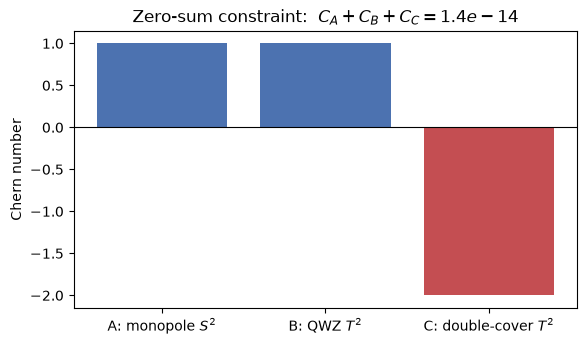

In [8]:
plt.figure(figsize=(6.5, 3.6))
labels = ["A: monopole $S^2$", "B: QWZ $T^2$", "C: double-cover $T^2$"]
plt.bar(labels, [C_A, C_B, C_C], color=["#4c72b0", "#4c72b0", "#c44e52"])
plt.axhline(0, color="k", lw=0.8)
plt.ylabel("Chern number")
plt.title(f"Zero-sum constraint:  $C_A + C_B + C_C = {C_A + C_B + C_C:.1e}$")
plt.show()

### The Zak phase in 1D: the SSH chain

In one dimension the Wilson loop around the closed Brillouin zone gives
the **Zak phase** — the polarization invariant of the Su–Schrieffer–Heeger
(SSH) chain,

$$H(k) = (v + w\cos k)\,\sigma_x + w\sin k\,\sigma_y,$$

which is $\pi$ in the topological phase ($v < w$) and $0$ in the trivial
phase ($v > w$).  `berry_phase` takes the eigenstates along a *closed*
path (index $n$ identified with index $0$) and returns the gauge-invariant
phase in $(-\pi, \pi]$.

In [9]:
def ssh(k, v, w):
    return (v + w * np.cos(k)) * sigmax() + w * np.sin(k) * sigmay()


def zak_phase(v, w, n=200):
    ks = np.linspace(0, 2 * np.pi, n, endpoint=False)
    psi = np.empty((n, 2), dtype=complex)
    for i, k in enumerate(ks):
        psi[i] = Qobj(ssh(k, v, w)).eigenstates()[1][0].full().reshape(-1)
    return berry.berry_phase(psi)


topo = zak_phase(v=1.0, w=2.0)
triv = zak_phase(v=2.0, w=1.0)
print(f"topological phase (v < w):  Zak = {topo:+.6f}  = {topo / np.pi:+.4f} pi")
print(f"trivial phase     (v > w):  Zak = {triv:+.6f}  = {triv / np.pi:+.4f} pi")

topological phase (v < w):  Zak = -3.141593  = -1.0000 pi
trivial phase     (v > w):  Zak = -0.000000  = -0.0000 pi


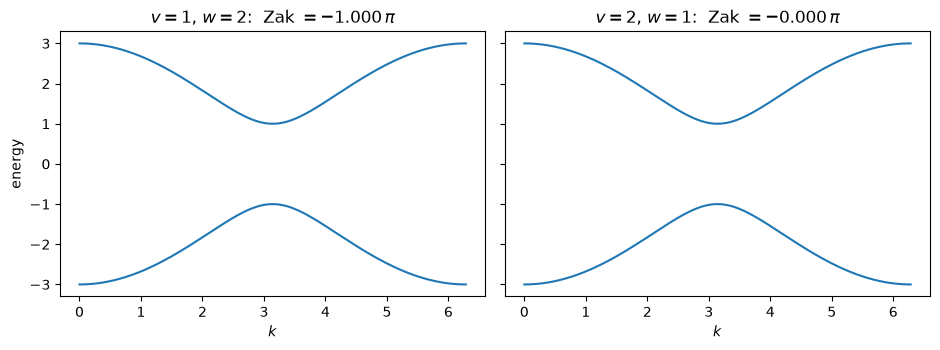

In [10]:
ks = np.linspace(0, 2 * np.pi, 200)
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.6), sharey=True)
for ax, (v, w), zak in [
    (axes[0], (1.0, 2.0), topo),
    (axes[1], (2.0, 1.0), triv),
]:
    bands = np.array([Qobj(ssh(k, v, w)).eigenenergies() for k in ks])
    ax.plot(ks, bands, color="tab:blue")
    ax.set_xlabel(r"$k$")
    ax.set_title(f"$v={v:g}$, $w={w:g}$:  Zak $= {zak / np.pi:+.3f}\,\pi$")
axes[0].set_ylabel("energy")
plt.tight_layout()
plt.show()

### Multi-band Wilson-loop formulation

When several eigenstates are supplied, the curvature is assembled from
the determinant of the Wilson loop around each plaquette — the
formulation of the original `qutip.topology` implementation — valid when
the bands do not mix.  As a stress test we build a 6-level Hamiltonian
with three well-separated monopole blocks of windings $(1, 1, 2)$; the
total Chern number over *all* bands must vanish.

In [11]:
def block_monopole(theta, phi):
    """Three decoupled monopole blocks with windings (1, 1, 2)."""
    H = np.zeros((6, 6), dtype=complex)
    for idx, (winding, scale) in enumerate([(1, 1.0), (1, 2.0), (2, 3.0)]):
        B = np.array([np.sin(theta) * np.cos(winding * phi),
                      np.sin(theta) * np.sin(winding * phi),
                      np.cos(theta)])
        block = B[0] * sigmax().full() + B[1] * sigmay().full() + B[2] * sigmaz().full()
        H[2 * idx:2 * idx + 2, 2 * idx:2 * idx + 2] = scale * block
    return Qobj(H)


thetas_6 = np.linspace(0, np.pi, 40)
phis_6 = np.linspace(0, 2 * np.pi, 40, endpoint=False)
psi_all = eigenstates_grid(block_monopole, thetas_6, phis_6)
print("eigenstate grid shape:", psi_all.shape)

C_multi = berry.chern_number(psi_all, periodic=(False, True))
print(f"total Chern number over all six bands: {C_multi:+.3e}")

eigenstate grid shape: (40, 40, 6, 6)
total Chern number over all six bands: -1.028e-15


Each occupied/empty band pair contributes $+1$ and $-1$, so the total is
zero up to the convergence of the determinant formulation on the finite
grid.

### Gauge invariance and exact quantization

Two properties of the toolkit are worth verifying directly.

First, **gauge invariance**: the invariants must be insensitive to local
U(1) re-gauging of the eigenstates.  We multiply every eigenstate by an
independent random phase and recompute $C$:

In [12]:
rng = np.random.default_rng(42)
phase = np.exp(1j * rng.uniform(0, 2 * np.pi, size=psi_mono.shape[:2]))
psi_gauged = psi_mono * phase[..., None]

C_orig = berry.chern_number(psi_mono, periodic=(False, True))
C_gauged = berry.chern_number(psi_gauged, periodic=(False, True))
print(f"original : C = {C_orig:+.12f}")
print(f"re-gauged: C = {C_gauged:+.12f}")

original : C = +1.000000000000
re-gauged: C = +1.000000000000


Second, **exact quantization**: with the FHS formulation the single-band
Chern number is exactly integral on *any* grid size, so it does not
drift as the mesh is refined — a qualitative advantage over naive
discretizations, where the result converges only slowly with an O(1/N)
error:

In [13]:
ns = [16, 24, 32, 48, 64, 96]
Cs = []
for n in ns:
    p0 = np.linspace(0, np.pi, n)
    p1 = np.linspace(0, 2 * np.pi, n, endpoint=False)
    psi_n = eigenstates_grid(monopole, p0, p1, bands=[0])
    Cs.append(berry.chern_number(psi_n, periodic=(False, True)))
    print(f"n = {n:3d}   C = {Cs[-1]:+.12f}")

n =  16   C = +1.000000000000


n =  24   C = +1.000000000000

n =  32   C = +1.000000000000


n =  48   C = +1.000000000000


n =  64   C = +1.000000000000


n =  96   C = +1.000000000000


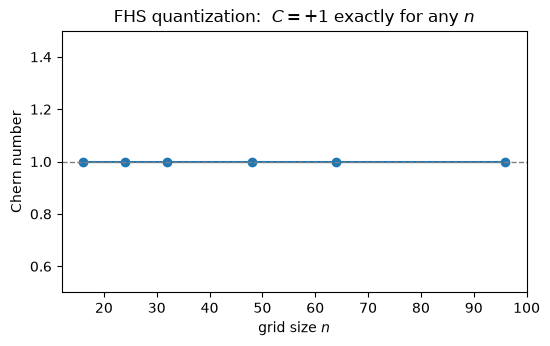

In [14]:
plt.figure(figsize=(6, 3.4))
plt.plot(ns, Cs, "o-")
plt.axhline(1, color="gray", ls="--", lw=1)
plt.xlabel("grid size $n$")
plt.ylabel("Chern number")
plt.ylim(0.5, 1.5)
plt.title("FHS quantization:  $C = +1$ exactly for any $n$")
plt.show()

### Summary

`qutip.berry` provides a compact, gauge-invariant numerical interface
for the geometric quantities of parameterized Hamiltonians:

| Quantity | Function | Demonstrated with |
|---|---|---|
| Berry curvature $F(\theta)$ | `berry_curvature(eigfs, periodic)` | monopole on $S^2$, QWZ on $T^2$ |
| Chern number $C$ | `chern_number(eigfs, periodic)` | $C = +1, -2$, exactly quantized |
| Berry/Zak phase | `berry_phase(eigfs)` | SSH chain: $\pi$ vs $0$ |
| Multi-band curvature | `berry_curvature` (nocc > 1) | 6-band block monopole, total $C = 0$ |
| Consistency test | `chern_number` per sector | $C_A + C_B + C_C = 0$ |

The zero-sum sector test doubles as a built-in end-to-end check: it
catches mesh errors and gauge errors simultaneously, because any defect
breaks the global constraint even when individual sectors look integer.

### References

- T. Fukui, Y. Hatsugai and H. Suzuki, *Chern Numbers in Discretized
  Brillouin Zone: Efficient Method of Computing (Spin) Hall
  Conductances*, J. Phys. Soc. Jpn. **74**, 1674 (2005).
- M. V. Berry, *Quantal phase factors accompanying adiabatic changes*,
  Proc. R. Soc. Lond. A **392**, 45 (1984).
- Feature request: [qutip/qutip#2972 — Parameter-space Berry curvature /
  Chern number toolbox with gauge-consistency test suite](https://github.com/qutip/qutip/issues/2972).

In [15]:
qutip.about()


QuTiP: Quantum Toolbox in Python
Copyright (c) QuTiP team 2011 and later.
Current admin team: Alexander Pitchford, Nathan Shammah, Shahnawaz Ahmed, Neill Lambert, Eric Giguère, Boxi Li, Simon Cross, Asier Galicia, Paul Menczel, and Patrick Hopf.
Board members: Daniel Burgarth, Robert Johansson, Anton F. Kockum, Franco Nori and Will Zeng.
Original developers: R. J. Johansson & P. D. Nation.
Previous lead developers: Chris Granade & A. Grimsmo.
Currently developed through wide collaboration. See https://github.com/qutip for details.

QuTiP Version:      5.4.0.dev0+fbfb1f8
Numpy Version:      2.5.2
Scipy Version:      1.17.1
Cython Version:     3.2.9
Matplotlib Version: 3.11.1
Python Version:     3.12.9
Number of CPUs:     12
BLAS Info:          Accelerate
INTEL MKL Ext:      None
Platform Info:      Darwin (x86_64)
Installation path:  /Users/oygb/Downloads/GeometryAI-Mac-Build/qutip/qutip

Installed QuTiP family packages
-------------------------------

No QuTiP family packages installe